# Train DeepONet on Fluent cell-center subdomains

This notebook uses the non-grid dataset. The trunk queries are original Fluent cell centers inside each subdomain, not a 256×256 raster grid. Branch sensors are exterior BC points plus interpolated interface points.

In [39]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import builtins
import sys
import os
import logging
import subprocess
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from datetime import datetime

MODULE_DIR = Path.cwd()

if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from deeponet_fluent_dataset import (
    build_fluent_deeponet_dataset,
    DeepONetCellDataset,
    deeponet_cell_collate_fn,
)

from fluent_deeponet import (
    FeatureNormalizer,
    DeepONet,
    train_deeponet_one_epoch,
    evaluate_deeponet,
    predict_cell_sample,
)

from eval_fluent_deeponet import select_sample_indices_by_ar

from plot import (
    plot_prediction_imshow_from_points,
    local_query_to_physical,
    select_samples_by_ar,
    collect_predictions_for_data,
)

torch.manual_seed(0)
np.random.seed(0)
rng = np.random.default_rng()
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cuda:2


In [2]:
comment = "AR 10-30 random interface 3 realizations"

In [3]:
def save_git_snapshot(run_dir):
    run_dir = Path(run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)

    commands = {
        "git_commit.txt": ["git", "rev-parse", "HEAD"],
        "git_status.txt": ["git", "status"],
        "git_diff.patch": ["git", "diff"],
        "git_diff_cached.patch": ["git", "diff", "--cached"],
    }

    for filename, command in commands.items():
        with open(run_dir / filename, "w", encoding="utf-8") as f:
            subprocess.run(command, stdout=f, stderr=subprocess.STDOUT)

today = datetime.now().strftime("%m%d%y")
output_root = Path("results")
output_root.mkdir(parents=True, exist_ok=True)
run_no = len([s for s in output_root.iterdir() if today in s.name]) + 1
output_str = f"{today}_{run_no}"
output_dir = output_root / output_str
output_dir.mkdir(parents=True, exist_ok=True)
save_git_snapshot(output_dir / "code_snapshot")
logger = logging.getLogger("pino")
logging.basicConfig(filename=output_dir / 'training.log', 
                    level=logging.INFO, 
                    force=True,
                    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
                    datefmt='%Y-%m-%d %H:%M:%S')

orig_print = builtins.print
def print(*args, sep=' ', end='\n', file=None, flush=False):
    orig_print(*args, sep=sep, end=end, file=file, flush=flush)
    msg = sep.join(map(str, args))
    logger.info(msg)
    
print("Training comment")
print(comment)

Training comment
AR 10-30 random interface 3 realizations


## Case file paths

In [4]:
ROOT_DIR = Path("/home/hantianl/Documents/PIDIF/runs_2d/rect_ar")

available_ars = list(range(1, 51))

case_files = {
    i: {
        "mesh": ROOT_DIR / f"rect_ar{i:02d}_1e-1mps_2c/rect_ar{i:02d}.msh.h5",
        "dat": ROOT_DIR / f"rect_ar{i:02d}_1e-1mps_2c/case2d.dat.h5",
    }
    for i in available_ars
}

# Quick path check for the ARs used below.
for ar in [10, 20, 30, 50]:
    print(ar, case_files[ar]["mesh"].exists(), case_files[ar]["dat"].exists())

10 True True
20 True True
30 True True
50 True True


# Training config

In [5]:
ARS = list(range(10, 31))
VALID_ARS = [20, 25, 30]
TRAIN_ARS = [ar for ar in ARS if ar not in VALID_ARS]

N_SUBDOMAINS_TRAIN = TRAIN_ARS
N_SUBDOMAINS_VALID = VALID_ARS
N_INTERFACE_POINTS = 256
N_WALL_POINTS = 256
INTERFACE_PLACEMENT = "random"
INTERFACE_JITTER = 0.0
MIN_SUBDOMAIN_WIDTH = 0.01
N_REALIZATIONS_TRAIN = 3

N_QUERY_TRAIN = None
N_QUERY_VALID = None
BATCH_SIZE = 20

bc_kwargs = {
    "inlet_u": 0.1,
    "inlet_v": 0.0,
    "inlet_T": 273.0,
    "outlet_p": 0.0,
    "top_T": 273.0,
    "bottom_T": 275.0,
    "wall_u": 0.0,
    "wall_v": 0.0,
}

## Build non-grid training/validation dataset

In [6]:
train_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    ar_list=TRAIN_ARS,
    n_subdomains=N_SUBDOMAINS_TRAIN,
    n_interface_points=N_INTERFACE_POINTS,
    n_boundary_points=N_WALL_POINTS,
    n_realizations=N_REALIZATIONS_TRAIN,
    interface_placement=INTERFACE_PLACEMENT,
    interface_jitter=INTERFACE_JITTER,
    min_subdomain_width=MIN_SUBDOMAIN_WIDTH,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
)

valid_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    ar_list=VALID_ARS,
    n_subdomains=N_SUBDOMAINS_VALID,
    n_interface_points=N_INTERFACE_POINTS,
    n_boundary_points=N_WALL_POINTS,
    interface_placement="fixed",
    interface_jitter=0,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
)

samples = train_data["samples"]
metadata = train_data["metadata"]
branch_channel_names = list(train_data["branch_channel_names"])
trunk_channel_names = list(train_data["trunk_channel_names"])
output_channel_names = list(train_data["output_channel_names"])

ars = np.asarray([int(round(m["aspect_ratio"])) for m in metadata], dtype=np.int64)
subdomain_ids = np.asarray([int(m["subdomain_id"]) for m in metadata], dtype=np.int64)
local_aspect_ratios = np.asarray([float(m["local_aspect_ratio"]) for m in metadata], dtype=np.float32)
n_cells = np.asarray([int(m["n_cells"]) for m in metadata], dtype=np.int64)

print("Train samples:", len(train_data["samples"]))
print("Valid samples:", len(valid_data["samples"]))

print("Train branch channels:", train_data["branch_channel_names"])
print("Train trunk channels:", train_data["trunk_channel_names"])
print("Output channels:", train_data["output_channel_names"])

print("Example train sample:")
print("branch:", train_data["samples"][0]["branch"].shape)
print("query:", train_data["samples"][0]["query"].shape)
print("target:", train_data["samples"][0]["target"].shape)

Processing AR=10 realization=0
Processing AR=10 realization=1
Processing AR=10 realization=2
Processing AR=11 realization=0
Processing AR=11 realization=1
Processing AR=11 realization=2
Processing AR=12 realization=0
Processing AR=12 realization=1
Processing AR=12 realization=2
Processing AR=13 realization=0
Processing AR=13 realization=1
Processing AR=13 realization=2
Processing AR=14 realization=0
Processing AR=14 realization=1
Processing AR=14 realization=2
Processing AR=15 realization=0
Processing AR=15 realization=1
Processing AR=15 realization=2
Processing AR=16 realization=0
Processing AR=16 realization=1
Processing AR=16 realization=2
Processing AR=17 realization=0
Processing AR=17 realization=1
Processing AR=17 realization=2
Processing AR=18 realization=0
Processing AR=18 realization=1
Processing AR=18 realization=2
Processing AR=19 realization=0
Processing AR=19 realization=1
Processing AR=19 realization=2
Processing AR=21 realization=0
Processing AR=21 realization=1
Processi

In [7]:
train_metadata = train_data["metadata"]
valid_metadata = valid_data["metadata"]

train_ars_array = np.asarray(
    [m["aspect_ratio"] for m in train_metadata],
    dtype=np.float32,
)

valid_ars_array = np.asarray(
    [m["aspect_ratio"] for m in valid_metadata],
    dtype=np.float32,
)

train_subdomain_ids = np.asarray(
    [m["subdomain_id"] for m in train_metadata],
    dtype=np.int64,
)

valid_subdomain_ids = np.asarray(
    [m["subdomain_id"] for m in valid_metadata],
    dtype=np.int64,
)

print("Train ARs:", sorted(set(train_ars_array.astype(int).tolist())))
print("Valid ARs:", sorted(set(valid_ars_array.astype(int).tolist())))

Train ARs: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 26, 27, 28, 29]
Valid ARs: [20, 25, 30]


In [8]:
def concatenate_targets(data):
    return np.concatenate(
        [sample["target"] for sample in data["samples"]],
        axis=0,
    ).astype(np.float32)


train_targets_all = concatenate_targets(train_data)

y_normalizer = FeatureNormalizer(train_targets_all)

print("Y mean:", y_normalizer.mean)
print("Y std:", y_normalizer.std)

train_local_aspects = np.asarray(
    [m["local_aspect_ratio"] for m in train_data["metadata"]],
    dtype=np.float32,
)

local_aspect_mean = float(train_local_aspects.mean())
local_aspect_std = float(train_local_aspects.std() + 1.0e-6)

print("local_aspect_mean:", local_aspect_mean)
print("local_aspect_std:", local_aspect_std)

Y mean: tensor([ 2.3686e-03,  2.7328e+02,  1.0007e-01, -1.0800e-07])
Y std: tensor([0.0017, 0.5126, 0.0354, 0.0006])
local_aspect_mean: 1.0
local_aspect_std: 0.7385977506637573


## DataLoaders

In [9]:
train_ds = DeepONetCellDataset(
    samples=train_data["samples"],
    sample_indices=None,
    n_query_points=N_QUERY_TRAIN,
    random_query=True,
    target_y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=train_data["branch_channel_names"],
)

valid_ds = DeepONetCellDataset(
    samples=valid_data["samples"],
    sample_indices=None,
    n_query_points=N_QUERY_VALID,
    random_query=False,
    target_y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=valid_data["branch_channel_names"],
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    collate_fn=deeponet_cell_collate_fn,
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    collate_fn=deeponet_cell_collate_fn,
)

branch_batch, query_batch, target_batch, query_batch_id, sample_idx_batch = next(iter(train_loader))

print("branch batch:", branch_batch.shape)
print("query batch:", query_batch.shape)
print("target batch:", target_batch.shape)
print("query batch id:", query_batch_id.min(), query_batch_id.max())
print("sample indices:", sample_idx_batch)

branch batch: torch.Size([20, 1024, 13])
query batch: torch.Size([262022, 2])
target batch: torch.Size([262022, 4])
query batch id: tensor(0) tensor(19)
sample indices: tensor([ 831,  440,  135,  737,  896,  926,  918,   92,  704,   49,   76, 1007,
         746,  916,  764,  558,  625,  101,  392, 1009])


## Model

In [10]:
branch_input_dim = train_data["samples"][0]["branch"].shape[-1]
trunk_input_dim = train_data["samples"][0]["query"].shape[-1]
output_channels = train_data["samples"][0]["target"].shape[-1]

model = DeepONet(
    branch_input_dim=branch_input_dim,
    trunk_input_dim=trunk_input_dim,
    output_channels=output_channels,
    latent_dim=128,
    branch_point_hidden_dim=128,
    branch_point_depth=3,
    branch_global_hidden_dim=128,
    branch_global_depth=3,
    trunk_hidden_dim=128,
    trunk_depth=4,
    aggregation="mean",
    activation="gelu",
    layer_norm=False,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1.0e-3, weight_decay=1.0e-4)
EPOCHS = 1000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(model.config())

{'branch_input_dim': 13, 'trunk_input_dim': 2, 'output_channels': 4, 'latent_dim': 128, 'branch_point_hidden_dim': 128, 'branch_point_depth': 3, 'branch_global_hidden_dim': 128, 'branch_global_depth': 3, 'trunk_hidden_dim': 128, 'trunk_depth': 4, 'aggregation': 'mean', 'activation': 'gelu', 'layer_norm': False}


## Train

In [33]:
checkpoint_path = output_dir / "checkpoint.pt"

LOSS_TYPE = "mse"
LAMBDA_BC = 0.1  # set to 0.0 to train only on sampled cell-center targets

best_valid_rel = float("inf")
history = []
y_normalizer = y_normalizer.to(DEVICE)

start = datetime.now()
for epoch in range(1, EPOCHS + 1):
    data_loss, bc_loss = train_deeponet_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=DEVICE,
        loss_type=LOSS_TYPE,
        lambda_bc=LAMBDA_BC,
        branch_channel_names=branch_channel_names,
    )
    scheduler.step()

    valid_metrics = evaluate_deeponet(
        model=model,
        loader=valid_loader,
        device=DEVICE,
        y_normalizer=y_normalizer,
    )
    valid_rel = valid_metrics["relative_l2"]
    valid_channel_rel = valid_metrics["channel_relative_l2"]

    history.append({
        "epoch": epoch,
        "data_loss": data_loss,
        "bc_loss": bc_loss,
        "valid_mse": valid_metrics["mse"],
        "valid_relative_l2": valid_rel,
        "valid_channel_relative_l2": valid_channel_rel,
    })

    if valid_rel < best_valid_rel:
        best_valid_rel = valid_rel
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "model_config": model.config(),
                "y_normalizer": y_normalizer.state_dict(),
                "branch_channel_names": train_data["branch_channel_names"],
                "trunk_channel_names": train_data["trunk_channel_names"],
                "output_channel_names": train_data["output_channel_names"],
                "train_ars": TRAIN_ARS,
                "valid_ars": VALID_ARS,
                "n_subdomains_train": N_SUBDOMAINS_TRAIN,
                "n_subdomains_valid": N_SUBDOMAINS_VALID,
                "n_interface_points": N_INTERFACE_POINTS,
                "n_wall_points": N_WALL_POINTS,
                "interface_placement": INTERFACE_PLACEMENT,
                "interface_jitter": INTERFACE_JITTER,
                "min_subdomain_width": MIN_SUBDOMAIN_WIDTH,
                "local_aspect_mean": local_aspect_mean,
                "local_aspect_std": local_aspect_std,
                "bc_kwargs": bc_kwargs,
            },
            checkpoint_path,
        )

    if epoch == 1 or epoch % 10 == 0:
        channel_msg = ", ".join(f"{name}={err:.3e}" for name, err in zip(output_channel_names, valid_channel_rel))
        print(
            f"Epoch {epoch:04d} | data loss={data_loss:.3e} | bc loss={bc_loss:.3e} | "
            f"valid MSE={valid_metrics['mse']:.3e} | valid rel L2={valid_rel:.3e} | {channel_msg} | "
            f"Time: {datetime.now() - start}"
        )

print("Best validation relative L2:", best_valid_rel)
print("Saved:", checkpoint_path)

loss_history_path = output_dir / f"loss_history.npz"
np.savez(
    loss_history_path,
    epoch=np.asarray([h["epoch"] for h in history], dtype=np.int32),
    data_loss=np.asarray([h["data_loss"] for h in history], dtype=np.float32),
    bc_loss=np.asarray([h["bc_loss"] for h in history], dtype=np.float32),
    valid_mse_phys=np.asarray([h["valid_mse"] for h in history], dtype=np.float32),
)

Epoch 0001 | data loss=4.920e-02 | bc loss=1.260e-02 | valid MSE=4.337e-04 | valid rel L2=1.379e-04 | pressure=3.948e-02, temperature=1.517e-04, u=3.621e-02, v=3.656e-01Time: 0:00:04.525930
Epoch 0010 | data loss=5.205e-02 | bc loss=1.306e-02 | valid MSE=3.444e-04 | valid rel L2=1.286e-04 | pressure=4.811e-02, temperature=1.351e-04, u=3.576e-02, v=3.452e-01Time: 0:00:44.743341
Epoch 0020 | data loss=2.578e-02 | bc loss=7.555e-03 | valid MSE=2.570e-04 | valid rel L2=1.137e-04 | pressure=1.990e-02, temperature=1.170e-04, u=2.308e-02, v=2.858e-01Time: 0:01:29.218266
Epoch 0030 | data loss=2.077e-02 | bc loss=6.320e-03 | valid MSE=3.448e-04 | valid rel L2=1.317e-04 | pressure=1.079e-02, temperature=1.356e-04, u=2.134e-02, v=2.624e-01Time: 0:02:14.191419
Epoch 0040 | data loss=1.662e-02 | bc loss=5.095e-03 | valid MSE=1.698e-04 | valid rel L2=8.898e-05 | pressure=2.894e-02, temperature=9.506e-05, u=1.919e-02, v=2.396e-01Time: 0:02:59.239329
Epoch 0050 | data loss=1.314e-02 | bc loss=4.102e-

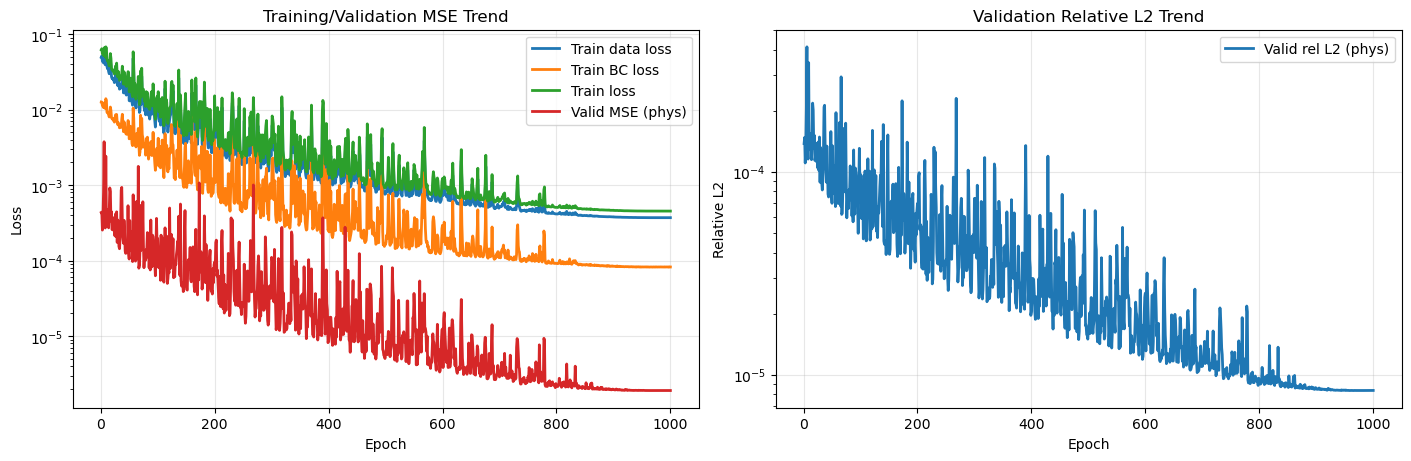

In [34]:
# Plot training/validation loss trend over iterations (epochs).
epochs = np.asarray([h["epoch"] for h in history])
data_loss_arr = np.asarray([h["data_loss"] for h in history])
bc_loss_arr = np.asarray([h["bc_loss"] for h in history])
train_loss_arr = data_loss_arr + bc_loss_arr
valid_loss_arr = np.asarray([h["valid_mse"] for h in history])
valid_rel_l2_arr = np.asarray([h["valid_relative_l2"] for h in history])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].plot(epochs, data_loss_arr, label="Train data loss", linewidth=2)
axes[0].plot(epochs, bc_loss_arr, label="Train BC loss", linewidth=2)
axes[0].plot(epochs, train_loss_arr, label="Train loss", linewidth=2)
axes[0].plot(epochs, valid_loss_arr, label="Valid MSE (phys)", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training/Validation MSE Trend")
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale("log")
axes[0].legend()

axes[1].plot(epochs, valid_rel_l2_arr, label="Valid rel L2 (phys)", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Relative L2")
axes[1].set_title("Validation Relative L2 Trend")
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale("log")
axes[1].legend()

plt.show()


## Load best checkpoint

In [35]:
ckpt = torch.load(checkpoint_path, map_location=DEVICE)

best_model = DeepONet(**ckpt["model_config"]).to(DEVICE)
best_model.load_state_dict(ckpt["model_state_dict"])
best_model.eval()

y_normalizer = FeatureNormalizer.from_state_dict(ckpt["y_normalizer"]).to(DEVICE)
local_aspect_mean = float(ckpt["local_aspect_mean"])
local_aspect_std = float(ckpt["local_aspect_std"])

print("Loaded:", checkpoint_path)

Loaded: results/052426_1/checkpoint.pt


/tmp/ipykernel_2828246/1104796799.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=DEVICE)


## Predict one validation subdomain at original cell centers

Saved: results/052426_1/predictions/validation/valid_sample_AR20.0_sub0_pressure.png


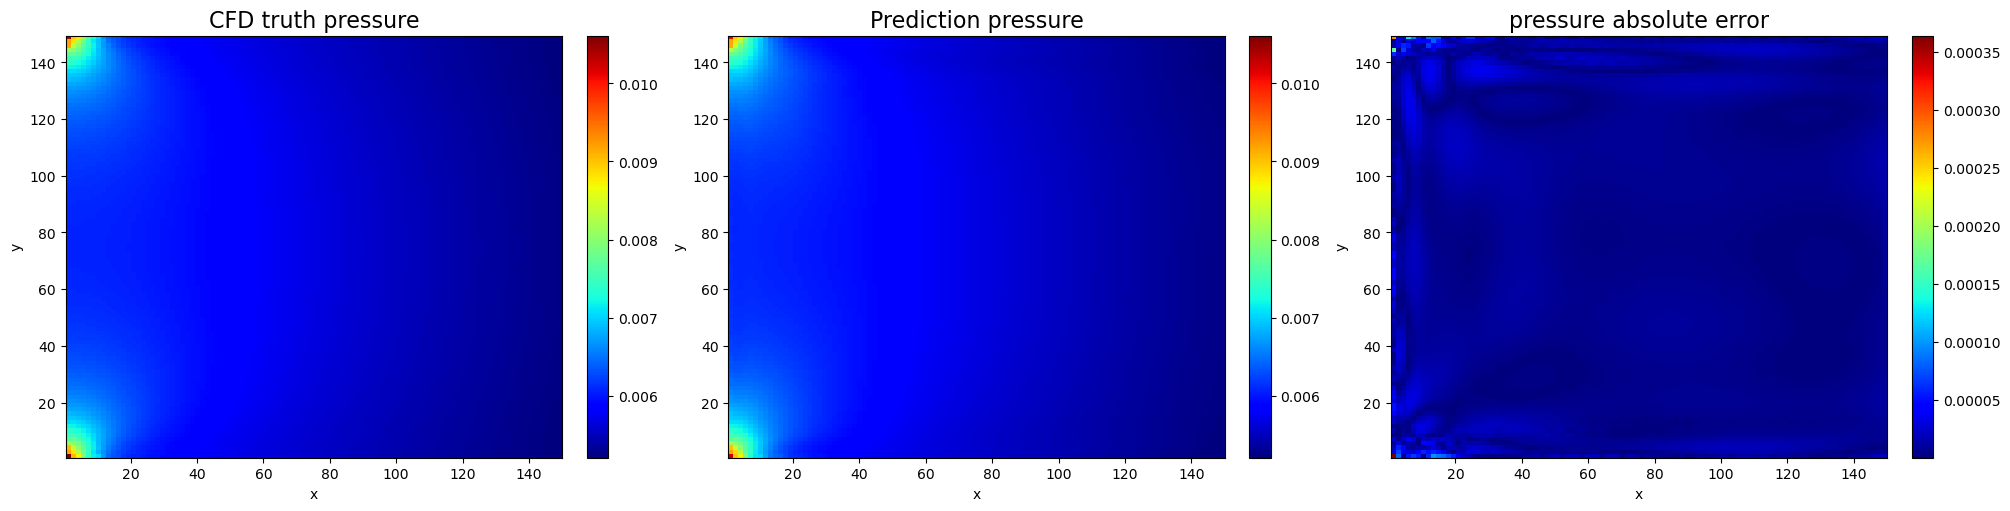

Saved: results/052426_1/predictions/validation/valid_sample_AR20.0_sub0_temperature.png


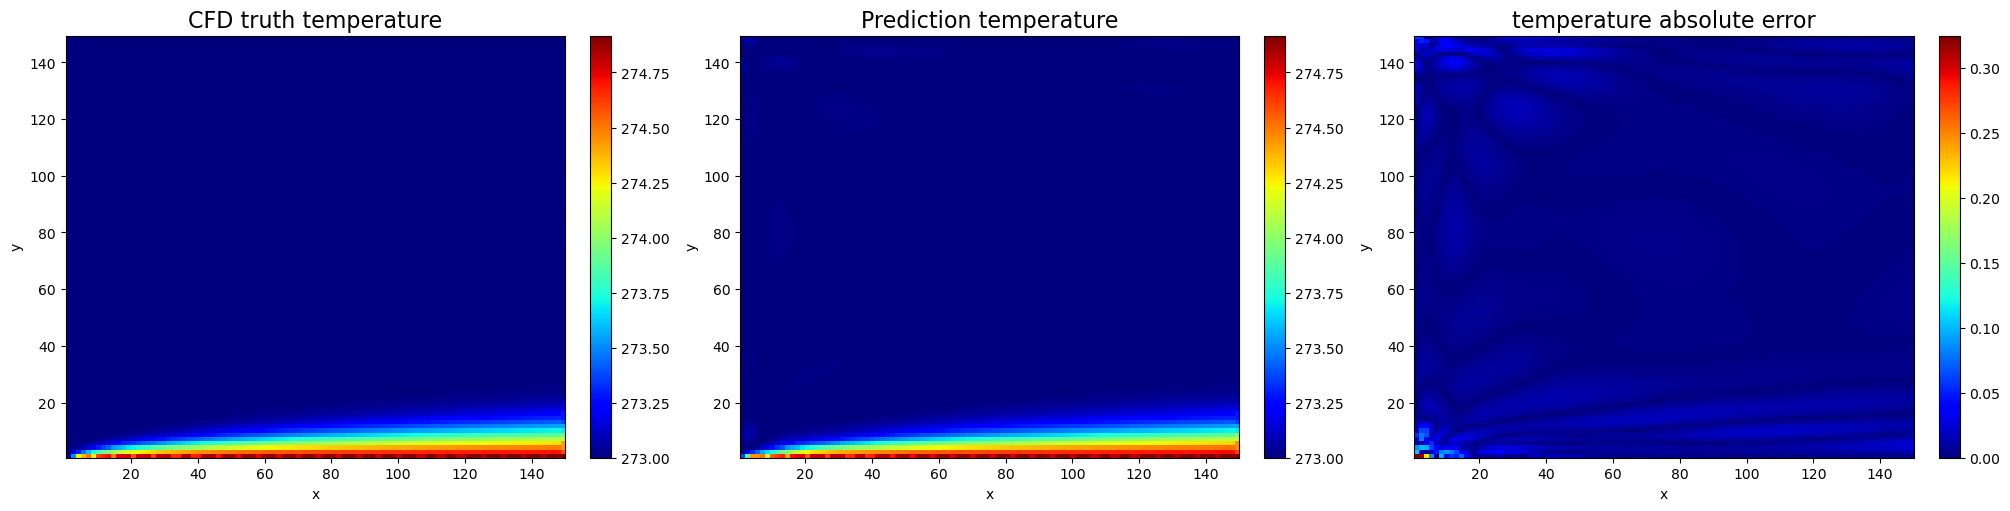

Saved: results/052426_1/predictions/validation/valid_sample_AR20.0_sub0_u.png


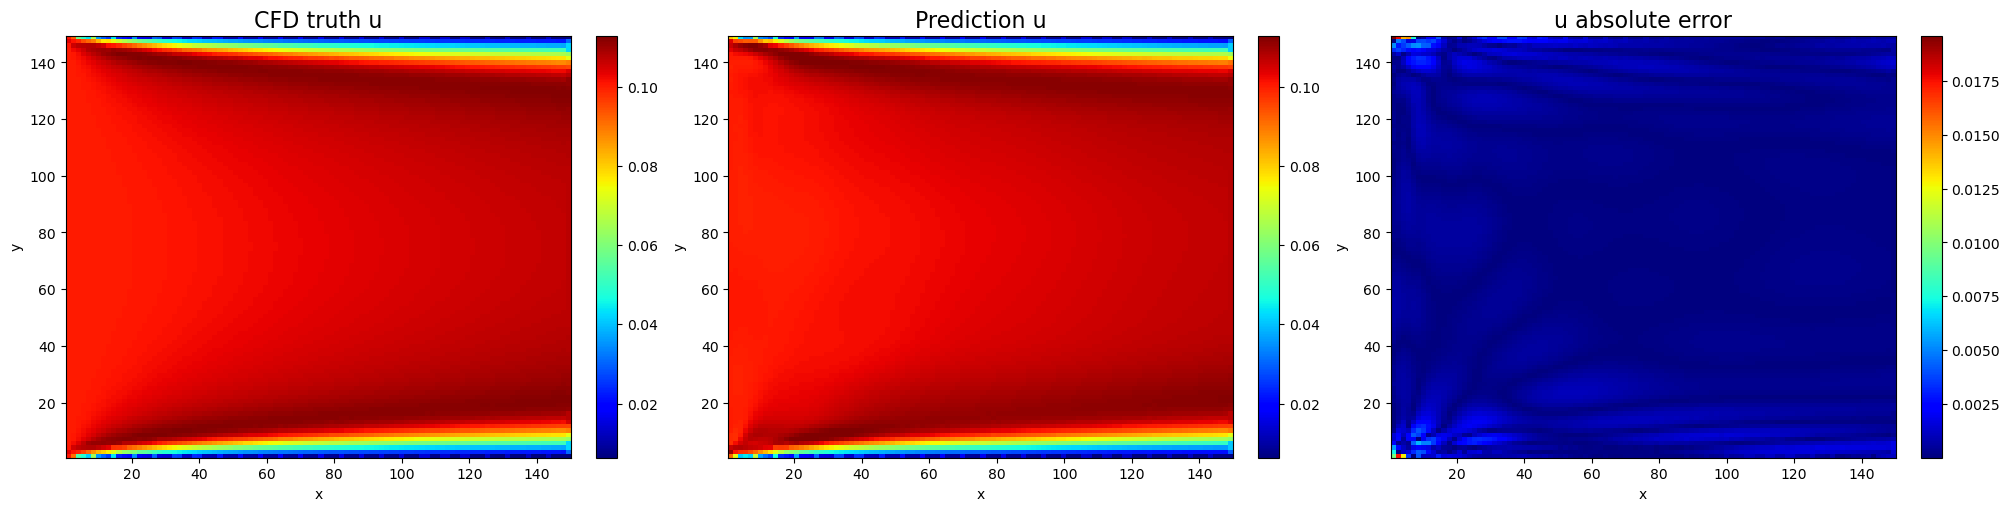

Saved: results/052426_1/predictions/validation/valid_sample_AR20.0_sub0_v.png


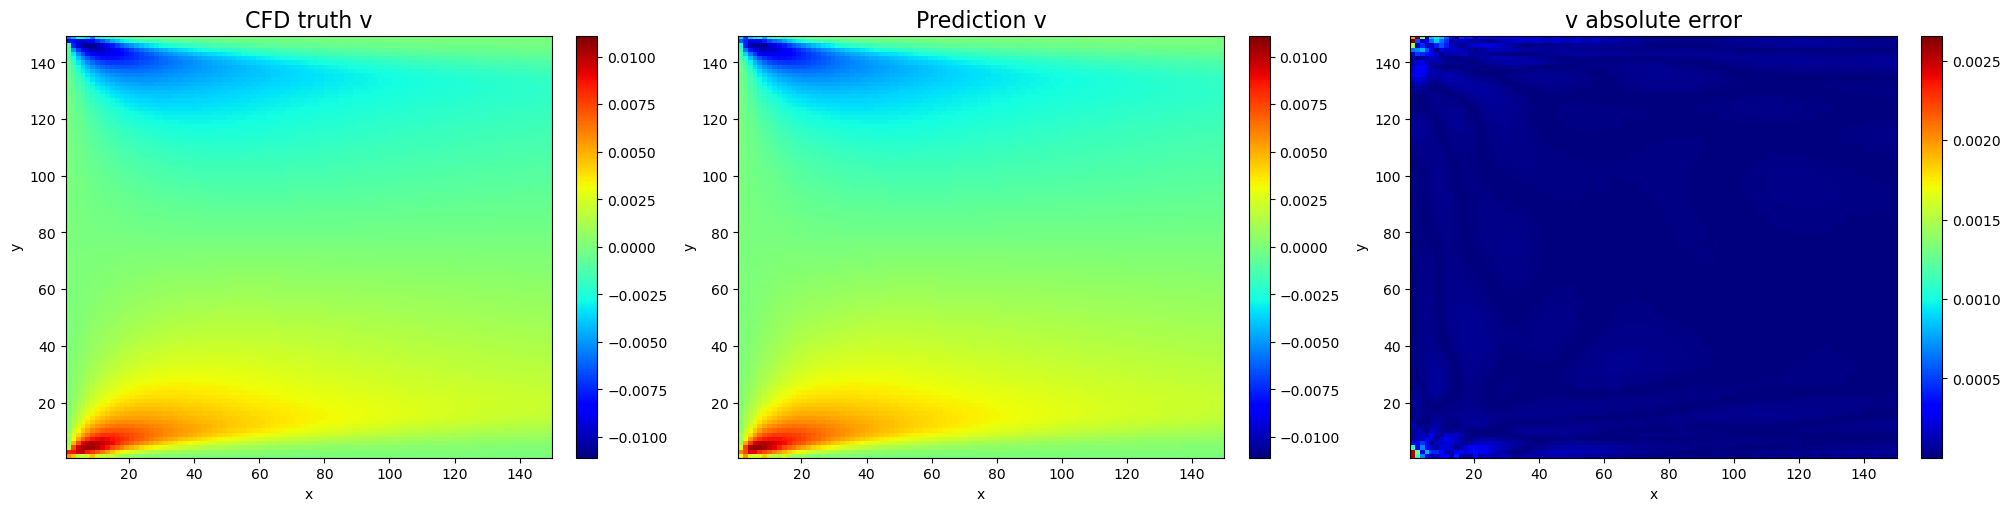

Total plotted points: 260696
x range: 0.5096231 2999.474
y range: 0.51863676 149.47418
Saved: results/052426_1/predictions/validation/valid_AR20_pressure.png


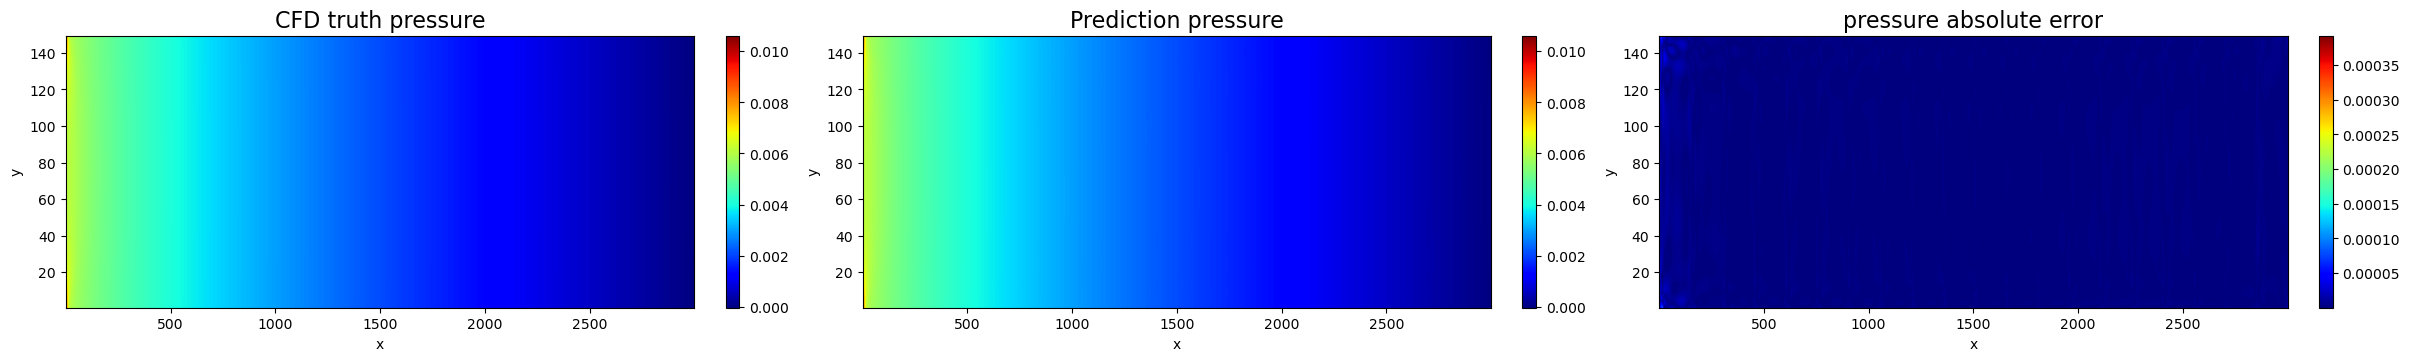

Saved: results/052426_1/predictions/validation/valid_AR20_temperature.png


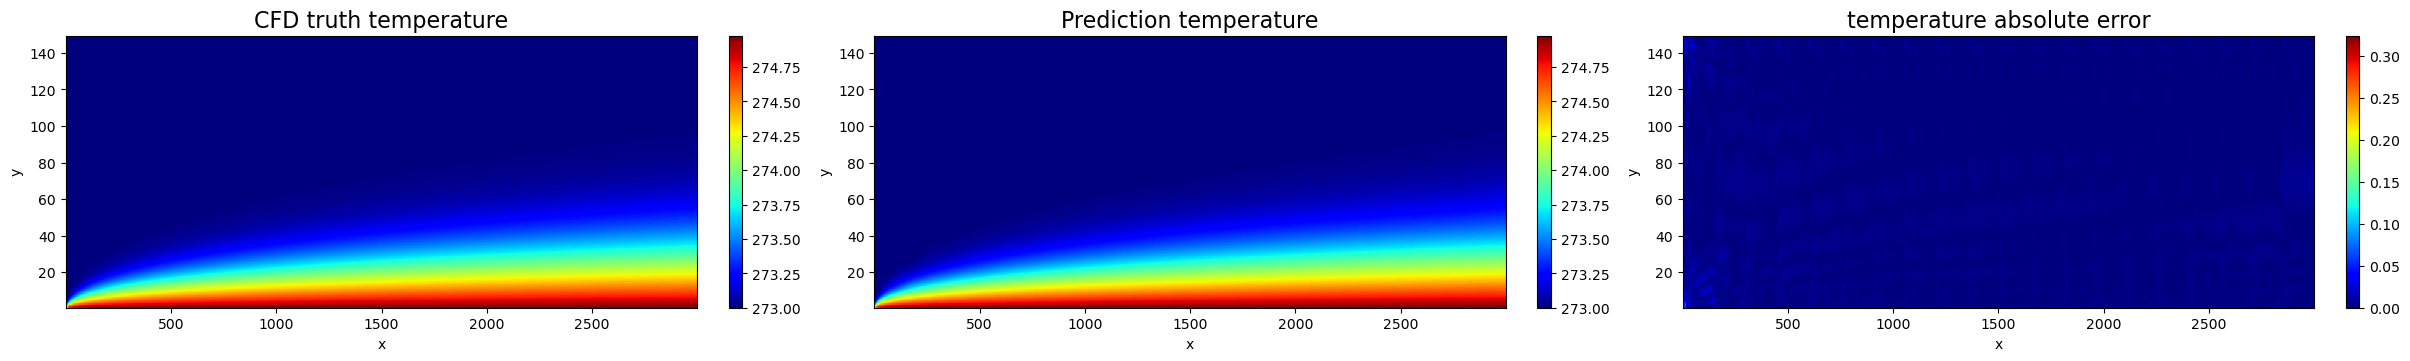

Saved: results/052426_1/predictions/validation/valid_AR20_u.png


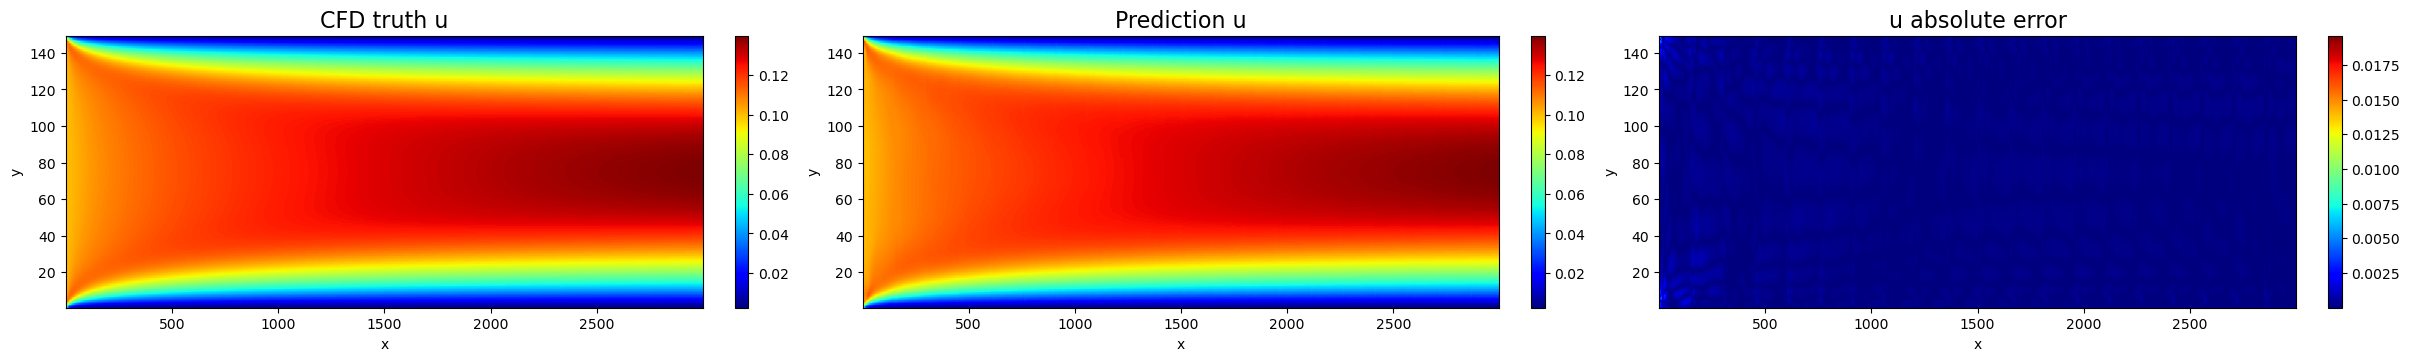

Saved: results/052426_1/predictions/validation/valid_AR20_v.png


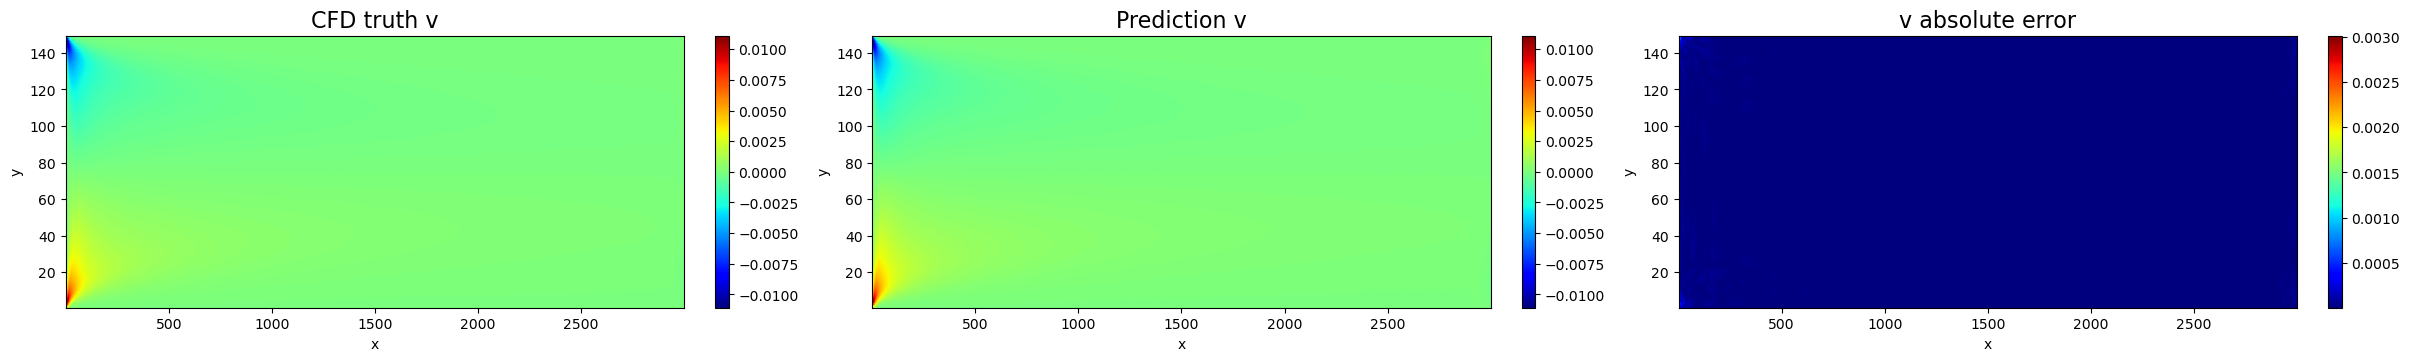

In [40]:
valid_sample_id = 0

sample = valid_data["samples"][valid_sample_id]
metadata = valid_data["metadata"][valid_sample_id]
output_channel_names = list(valid_data["output_channel_names"])

pred_phys = predict_cell_sample(
    model=model,
    sample=sample,
    device=DEVICE,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=valid_data["branch_channel_names"],
)

query_local = np.asarray(sample["query"], dtype=np.float32)
truth_phys = np.asarray(sample["target"], dtype=np.float32)

x_phys, y_phys = local_query_to_physical(query_local, metadata)

for field_idx, field_name in enumerate(output_channel_names):
    plot_prediction_imshow_from_points(
        x=x_phys,
        y=y_phys,
        pred=pred_phys,
        truth=truth_phys,
        field_name=field_name,
        field_idx=field_idx,
        figsize=(20, 5),
        n_y_plot=100,
        output_dir=output_dir / "predictions" / "validation",
        filename_prefix=f"valid_sample_AR{metadata['aspect_ratio']}_sub{metadata['subdomain_id']}",
    )
    
AR_TO_PLOT = int(VALID_ARS[0])

valid_ar_sample_ids = select_samples_by_ar(valid_data, AR_TO_PLOT)

plot_data = collect_predictions_for_data(
    model=model,
    data=valid_data,
    device=DEVICE,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    sample_indices=valid_ar_sample_ids,
)

print("Total plotted points:", plot_data["x"].shape[0])
print("x range:", plot_data["x"].min(), plot_data["x"].max())
print("y range:", plot_data["y"].min(), plot_data["y"].max())

for field_name in output_channel_names:
    field_idx = output_channel_names.index(field_name)

    plot_prediction_imshow_from_points(
        x=plot_data["x"],
        y=plot_data["y"],
        pred=plot_data["pred"],
        truth=plot_data["truth"],
        field_name=field_name,
        field_idx=field_idx,
        n_x_plot=100 * AR_TO_PLOT,
        n_y_plot=100,
        output_dir=output_dir / "predictions" / "validation",
        filename_prefix=f"valid_AR{AR_TO_PLOT}",
    )

Processing AR=50 realization=0
Saved: results/052426_1/predictions/test/test_sample_AR50.0_sub0_pressure.png


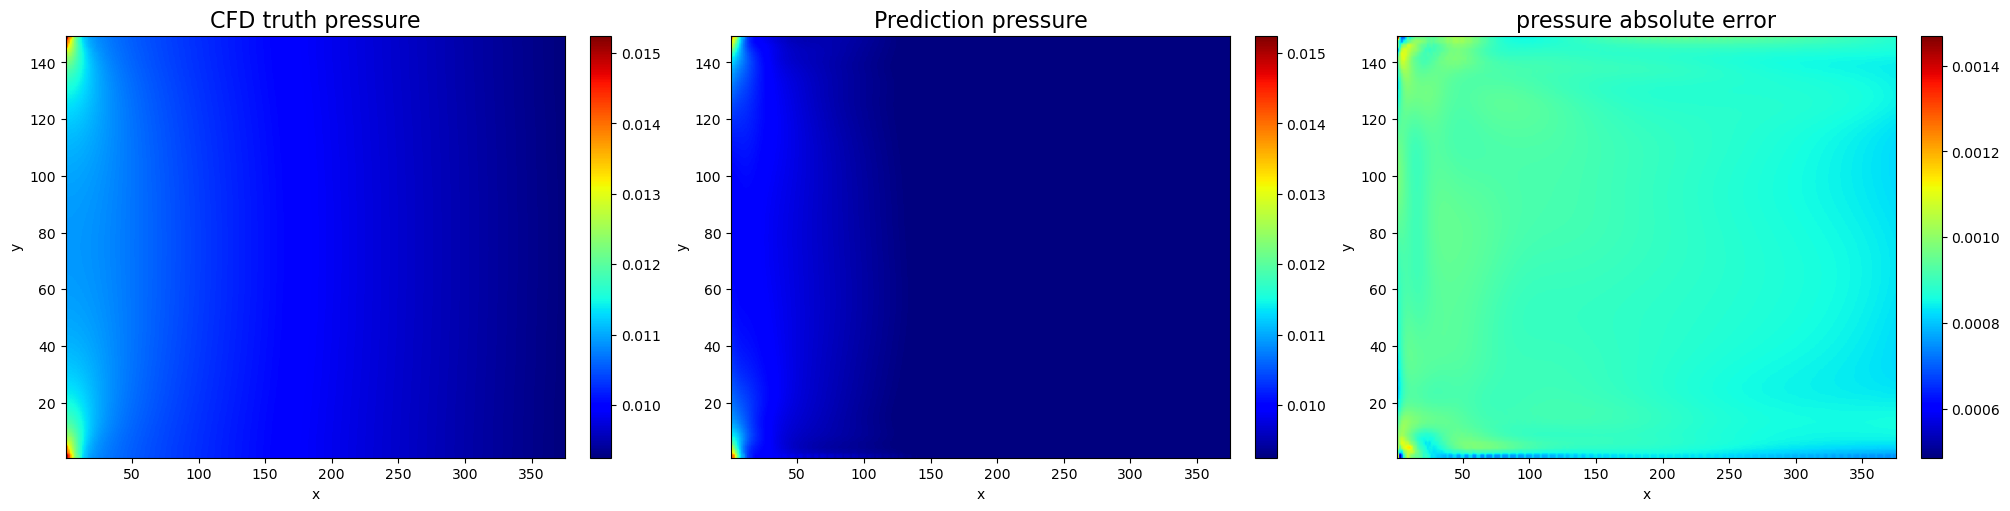

Saved: results/052426_1/predictions/test/test_sample_AR50.0_sub0_temperature.png


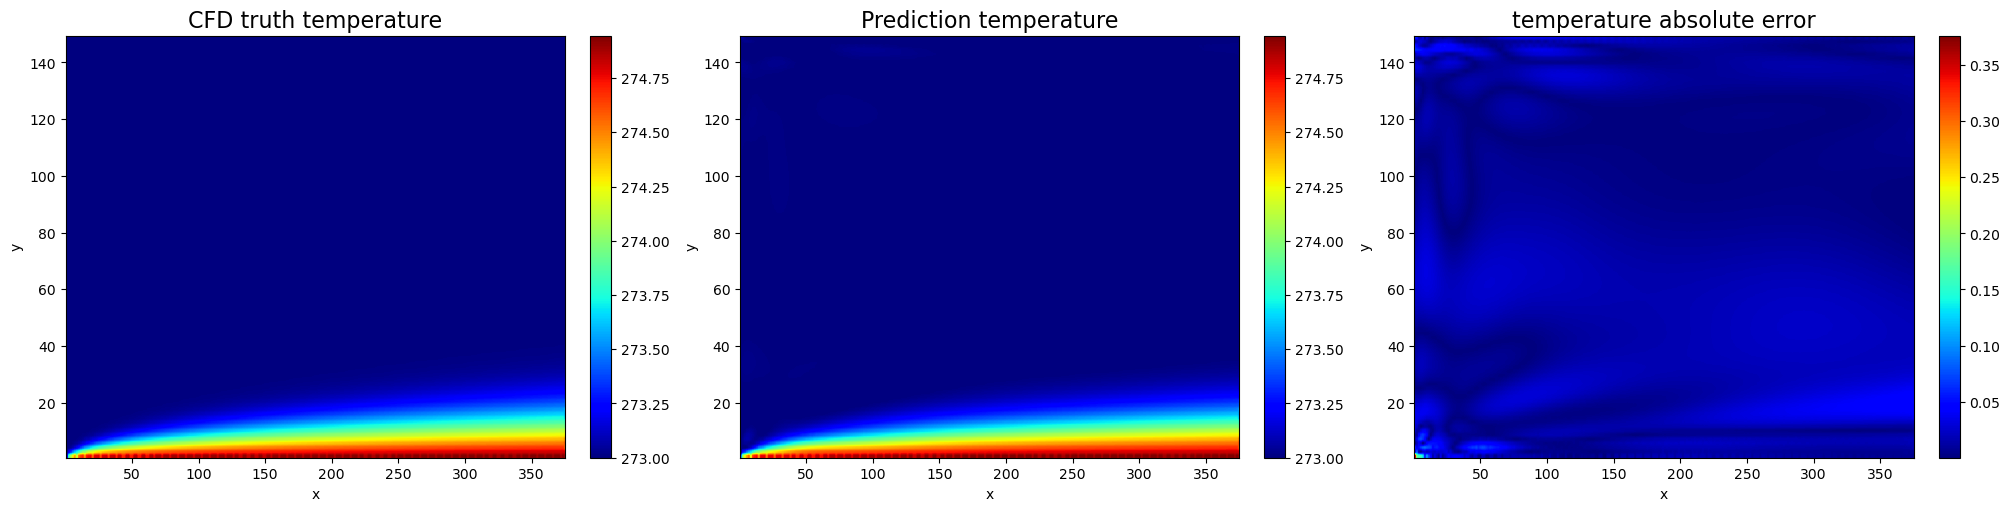

Saved: results/052426_1/predictions/test/test_sample_AR50.0_sub0_u.png


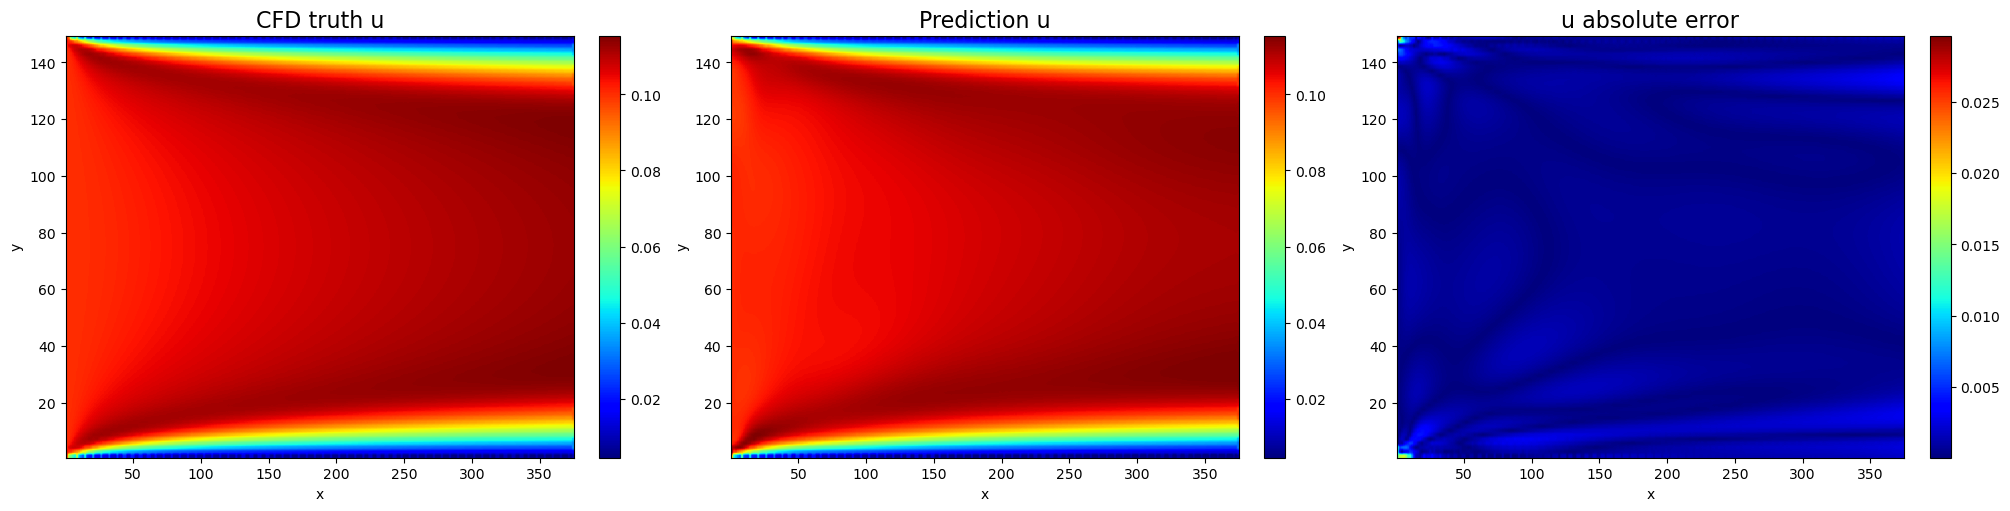

Saved: results/052426_1/predictions/test/test_sample_AR50.0_sub0_v.png


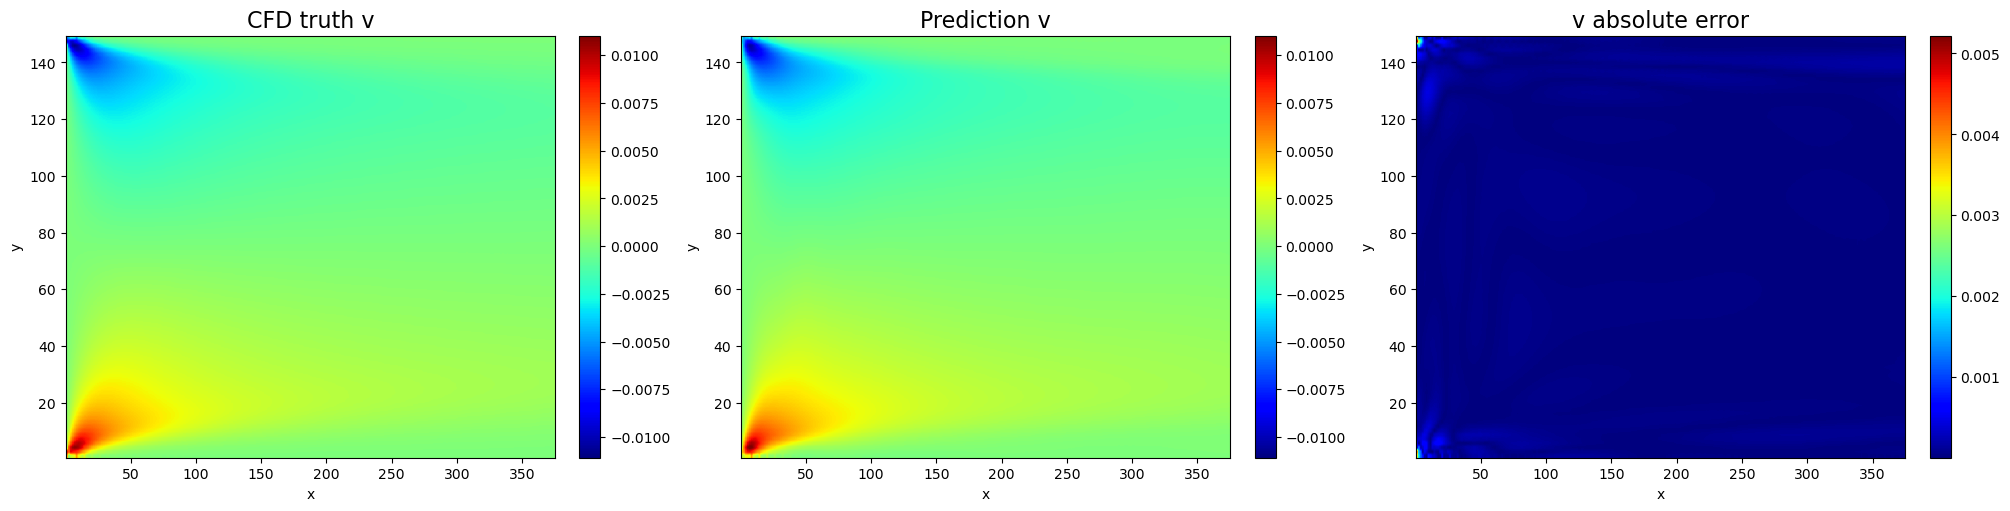

Total plotted points: 651482
x range: 0.5120154 7499.4707
y range: 0.5280181 149.4933
Saved: results/052426_1/predictions/test/test_AR20_pressure.png


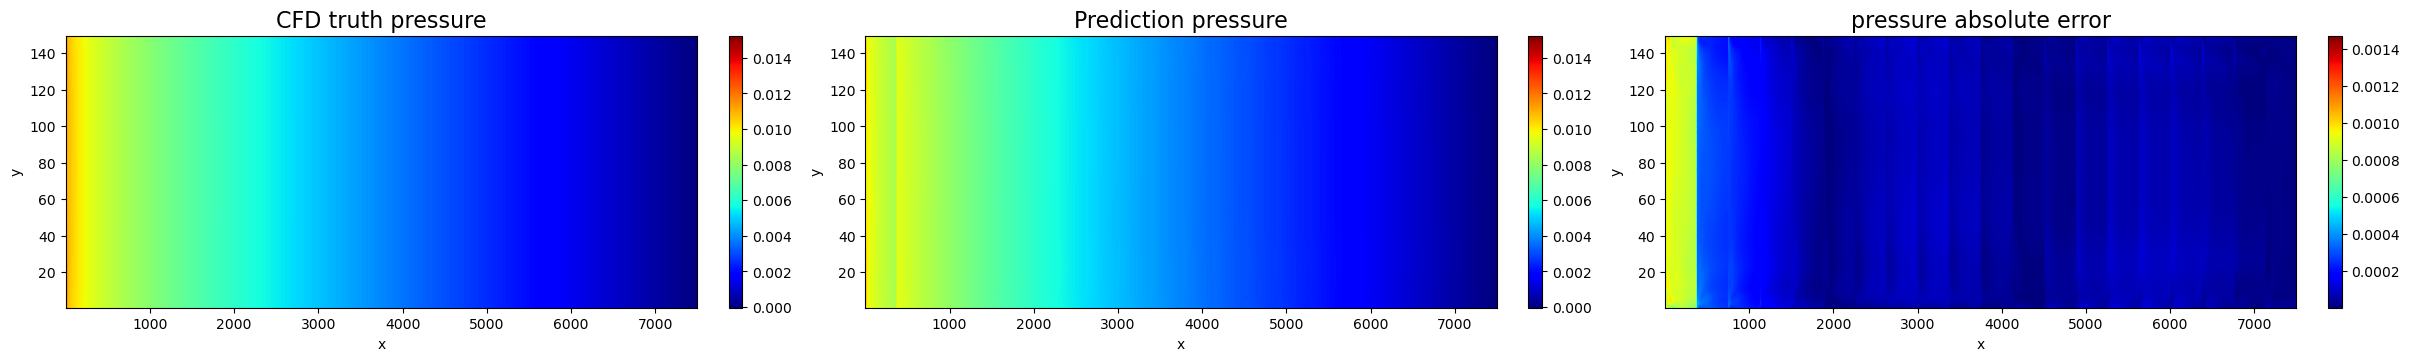

Saved: results/052426_1/predictions/test/test_AR20_temperature.png


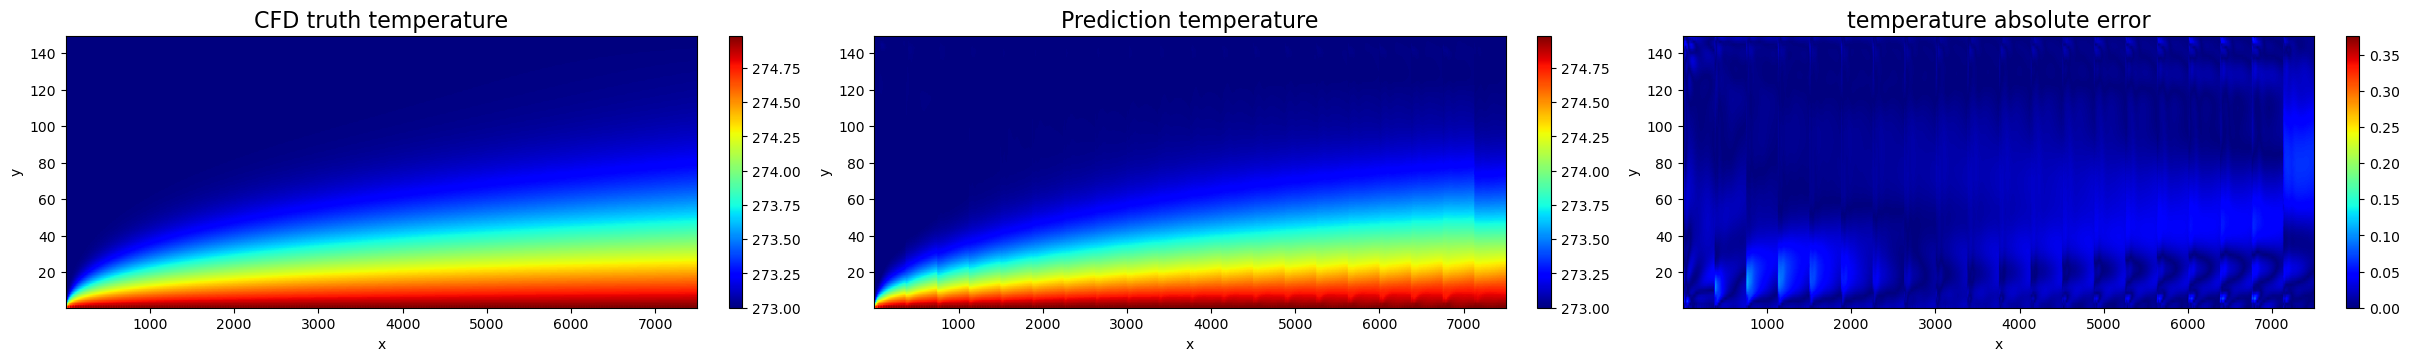

Saved: results/052426_1/predictions/test/test_AR20_u.png


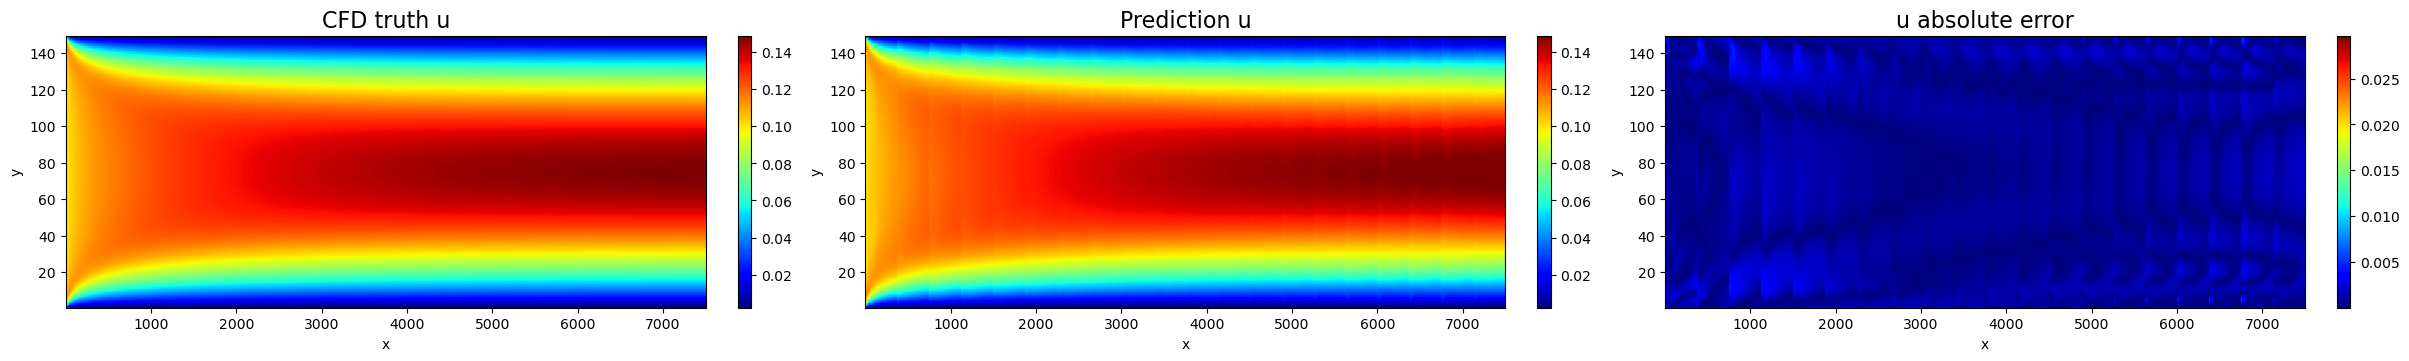

Saved: results/052426_1/predictions/test/test_AR20_v.png


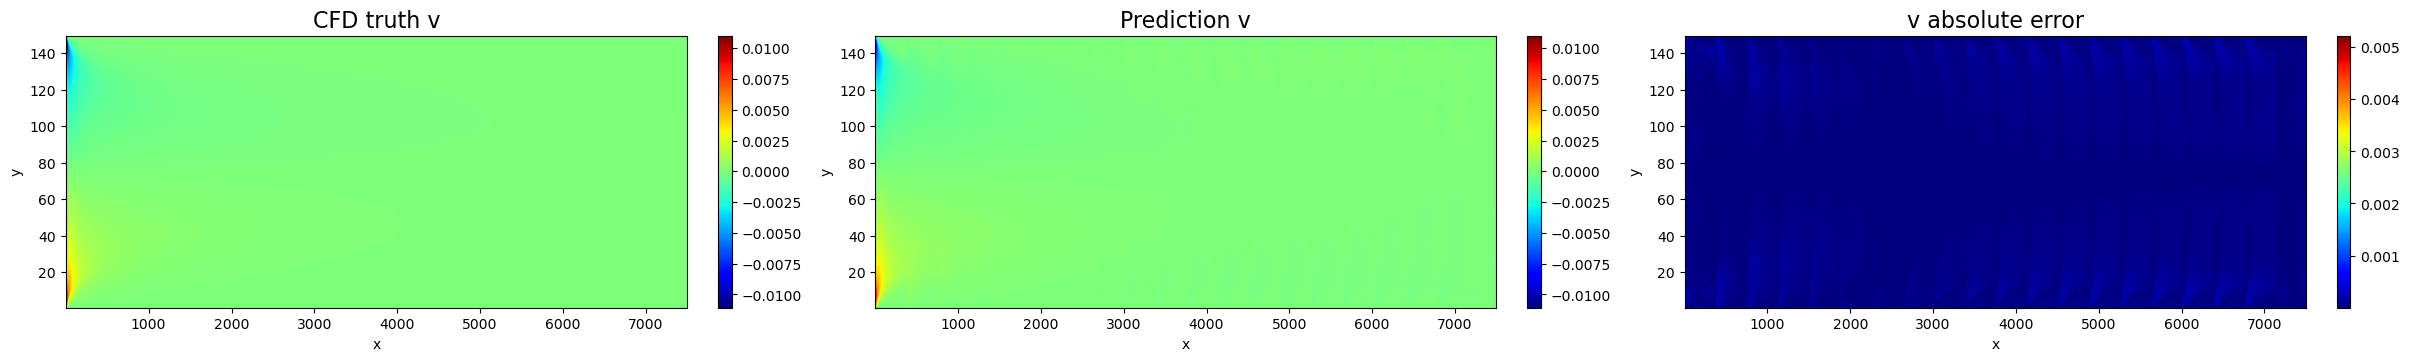

In [42]:
test_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    ar_list=[50],
    n_subdomains=20,
    n_interface_points=N_INTERFACE_POINTS,
    n_boundary_points=N_WALL_POINTS,
    interface_placement="fixed",
    interface_jitter=0,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
)
test_sample_id = 0

sample = test_data["samples"][test_sample_id]
metadata = test_data["metadata"][test_sample_id]
output_channel_names = list(test_data["output_channel_names"])

pred_phys = predict_cell_sample(
    model=model,
    sample=sample,
    device=DEVICE,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=valid_data["branch_channel_names"],
)

query_local = np.asarray(sample["query"], dtype=np.float32)
truth_phys = np.asarray(sample["target"], dtype=np.float32)

x_phys, y_phys = local_query_to_physical(query_local, metadata)

for field_idx, field_name in enumerate(output_channel_names):
    plot_prediction_imshow_from_points(
        x=x_phys,
        y=y_phys,
        pred=pred_phys,
        truth=truth_phys,
        field_name=field_name,
        field_idx=field_idx,
        figsize=(20, 5),
        n_y_plot=100,
        output_dir=output_dir / "predictions" / "test",
        filename_prefix=f"test_sample_AR{metadata['aspect_ratio']}_sub{metadata['subdomain_id']}",
    )
    

sample_test_ids = select_sample_indices_by_ar(test_data, ar=50)

plot_data = collect_predictions_for_data(
    model=model,
    data=test_data,
    device=DEVICE,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    sample_indices=sample_test_ids,
)

print("Total plotted points:", plot_data["x"].shape[0])
print("x range:", plot_data["x"].min(), plot_data["x"].max())
print("y range:", plot_data["y"].min(), plot_data["y"].max())

for field_name in output_channel_names:
    field_idx = output_channel_names.index(field_name)

    plot_prediction_imshow_from_points(
        x=plot_data["x"],
        y=plot_data["y"],
        pred=plot_data["pred"],
        truth=plot_data["truth"],
        field_name=field_name,
        field_idx=field_idx,
        n_x_plot=100 * AR_TO_PLOT,
        n_y_plot=100,
        output_dir=output_dir / "predictions" / "test",
        filename_prefix=f"test_AR{AR_TO_PLOT}",
    )